<a href="https://colab.research.google.com/github/maierav/ai_oscp_neuro/blob/main/notebooks/ccf_penetration_figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maierav/ai_oscp_neuro/blob/main/notebooks/ccf_penetration_figures.ipynb)

# OpenScope Predictive Processing — CCF Penetration Figures

Reproduce the 3D penetration renders and per-probe laminar cross-check figures for
any CCF-labeled ecephys session in **DANDI 001637**, and build the attachable CCF
sidecar tables.

**Runtime:** CPU is fine. Each session streams ~10–15 GB over HTTP via `remfile`
(no full download); a figure pair takes ~10–20 s. Open in Colab and run top to bottom.


In [1]:
#@title Install dependencies
!pip -q install pynwb h5py remfile requests pandas numpy scipy matplotlib pyarrow
# brainglobe-atlasapi is optional (only needed for the translucent brain shell in 3D)
!pip -q install brainglobe-atlasapi 2>/dev/null || echo "brainglobe optional - skipping"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.3/362.3 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 9.3 MB/s eta 0:00:00


In [2]:
#@title Get the package
import os
if not os.path.exists('openscope_ccf'):
    !git clone -q https://github.com/maierav/ai_oscp_neuro.git
    %cd ai_oscp_neuro
import sys; sys.path.insert(0,'.')
import openscope_ccf as o
print('openscope_ccf', o.__version__)


/content/ai_oscp_neuro
openscope_ccf 0.1.0


## 1. Pick a session
The registry lists all CCF-labeled sessions with subject, date, paradigm and DANDI asset id.

In [3]:
idx = o.load_session_index()
idx

,subject,date,paradigm,n_units,gb,aid,ccf,ccf_xyz
0,830795,2026-02-26-16-01-33,duration,2225,10.1,c9024a36-e476-4ffc-9e12-666e6ed3aec7,True,True
1,820459,2025-11-10-15-07-13,sensorimotor,4346,14.6,e3cbee16-232a-4874-8b7e-cfbaebdfeeaf,True,True
2,830849,2026-03-07-09-48-16,sensorimotor,2287,10.3,ab8ec755-2b87-45c3-a29d-dd88955334b8,True,True
3,830794,2026-01-28-11-01-44,sequence,2951,11.3,6068eec9-d614-471c-aa33-0ab27dc66475,True,True
4,830852,2026-02-23-10-31-02,sensorimotor,3622,13.6,e15084a4-6372-4a2a-90a7-64ef0e4450b0,True,True
5,830851,2026-03-17-10-46-04,standard_oddball,3122,12.8,9b9e8abe-7b43-47f1-b8e1-4114f87898a1,True,True
6,830848,2026-03-05-16-07-50,sensorimotor,2570,12.0,c53ec231-46f7-42d6-b89a-19e260b8eaa9,True,True
7,830848,2026-03-04-15-34-54,standard_oddball,3117,12.8,228c2c2e-1daf-4bf6-9f66-eb6b2bce5ba5,True,True
8,830846,2026-03-12-11-09-13,sensorimotor,2943,12.6,f2b15614-c07b-4187-9ace-f73b6e55005e,True,True
9,830846,2026-03-09-10-32-54,sequence,3550,13.7,03973a42-cf55-476f-80d7-85bc402fa57b,True,True


In [4]:
#@title Choose one session
subject = 820459 #@param {type:"integer"}
row = idx[idx.subject==subject].iloc[0]
tag = f"{row.subject}_{row.date}"
print("session:", tag, "|", row.paradigm, "|", row.n_units, "units")

session: 820459_2025-11-10-15-07-13 | sensorimotor | 4346 units


## 2. Build the CCF sidecars (attachable tables)
One per-unit and one per-channel Parquet, keyed to the NWB `units` / `electrodes` row indices.

In [5]:
paths = o.build_session_sidecars(row.aid, str(row.subject), row.date, row.paradigm)
import pandas as pd
units = pd.read_parquet(paths['units'])
print("unit sidecar:", units.shape, "| QC units:", units.qc_pass.sum())
units.head()

unit sidecar: (4346, 15) | QC units: 2322


,unit_index,subject,date,paradigm,probe,ccf_acronym,area,layer,group,tissue,qc_pass,firing_rate,ccf_ap,ccf_dv,ccf_ml
0,0,820459,2025-11-10-15-07-13,sensorimotor,ProbeA,LD,LD,None,thalamus,grey,True,11.169914,6500.0,3650.0,4625.0
1,1,820459,2025-11-10-15-07-13,sensorimotor,ProbeA,LD,LD,None,thalamus,grey,True,17.291614,6500.0,3650.0,4625.0
2,2,820459,2025-11-10-15-07-13,sensorimotor,ProbeA,LD,LD,None,thalamus,grey,True,18.475508,6500.0,3625.0,4625.0
3,3,820459,2025-11-10-15-07-13,sensorimotor,ProbeA,LD,LD,None,thalamus,grey,True,3.079627,6500.0,3625.0,4625.0
4,4,820459,2025-11-10-15-07-13,sensorimotor,ProbeA,LD,LD,None,thalamus,grey,True,10.553838,6500.0,3650.0,4625.0


### Attach CCF onto any analysis
Any result table that carries `unit_index` (SUA/MUA) or `electrode_row`/`channel`
(LFP/CSD) can be annotated in one call:

In [6]:
import numpy as np
my_result = pd.DataFrame({'unit_index': np.arange(len(units)),
                          'response': np.random.rand(len(units))})
annotated = o.attach(my_result, tag, on='unit_index')
annotated[['unit_index','response','area','layer','group']].head()

,unit_index,response,area,layer,group
0,0,0.089833,LD,None,thalamus
1,1,0.272209,LD,None,thalamus
2,2,0.869688,LD,None,thalamus
3,3,0.756162,LD,None,thalamus
4,4,0.823633,LD,None,thalamus


## 3. Penetration figures
### 3D atlas context (best-fit tracks)

Output()

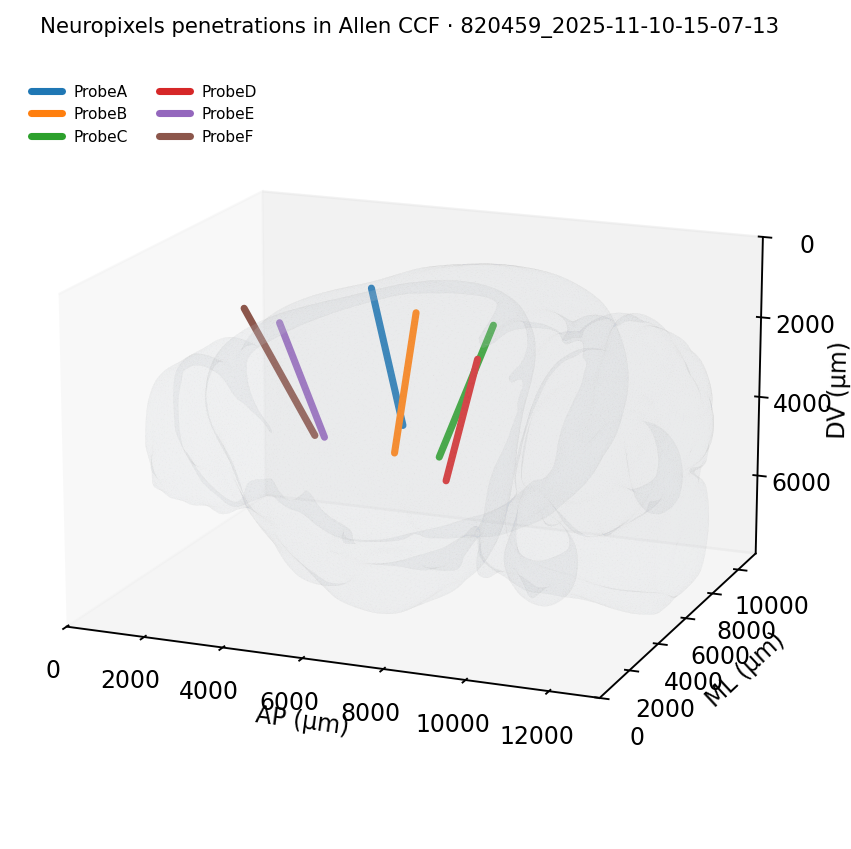

In [7]:
pd_ = o.build_probe_data(row.aid)
mesh = None
try:
    mesh = o.load_root_mesh()   # translucent Allen brain shell (optional)
except Exception as e:
    print("brain shell unavailable, rendering without it:", str(e)[:80])
o.make_3d(pd_, tag, "fig_3d.png", brain_mesh=mesh)
from IPython.display import Image; Image("fig_3d.png")

### Laminar cross-check: CCF region/layer vs LFP power & MUA

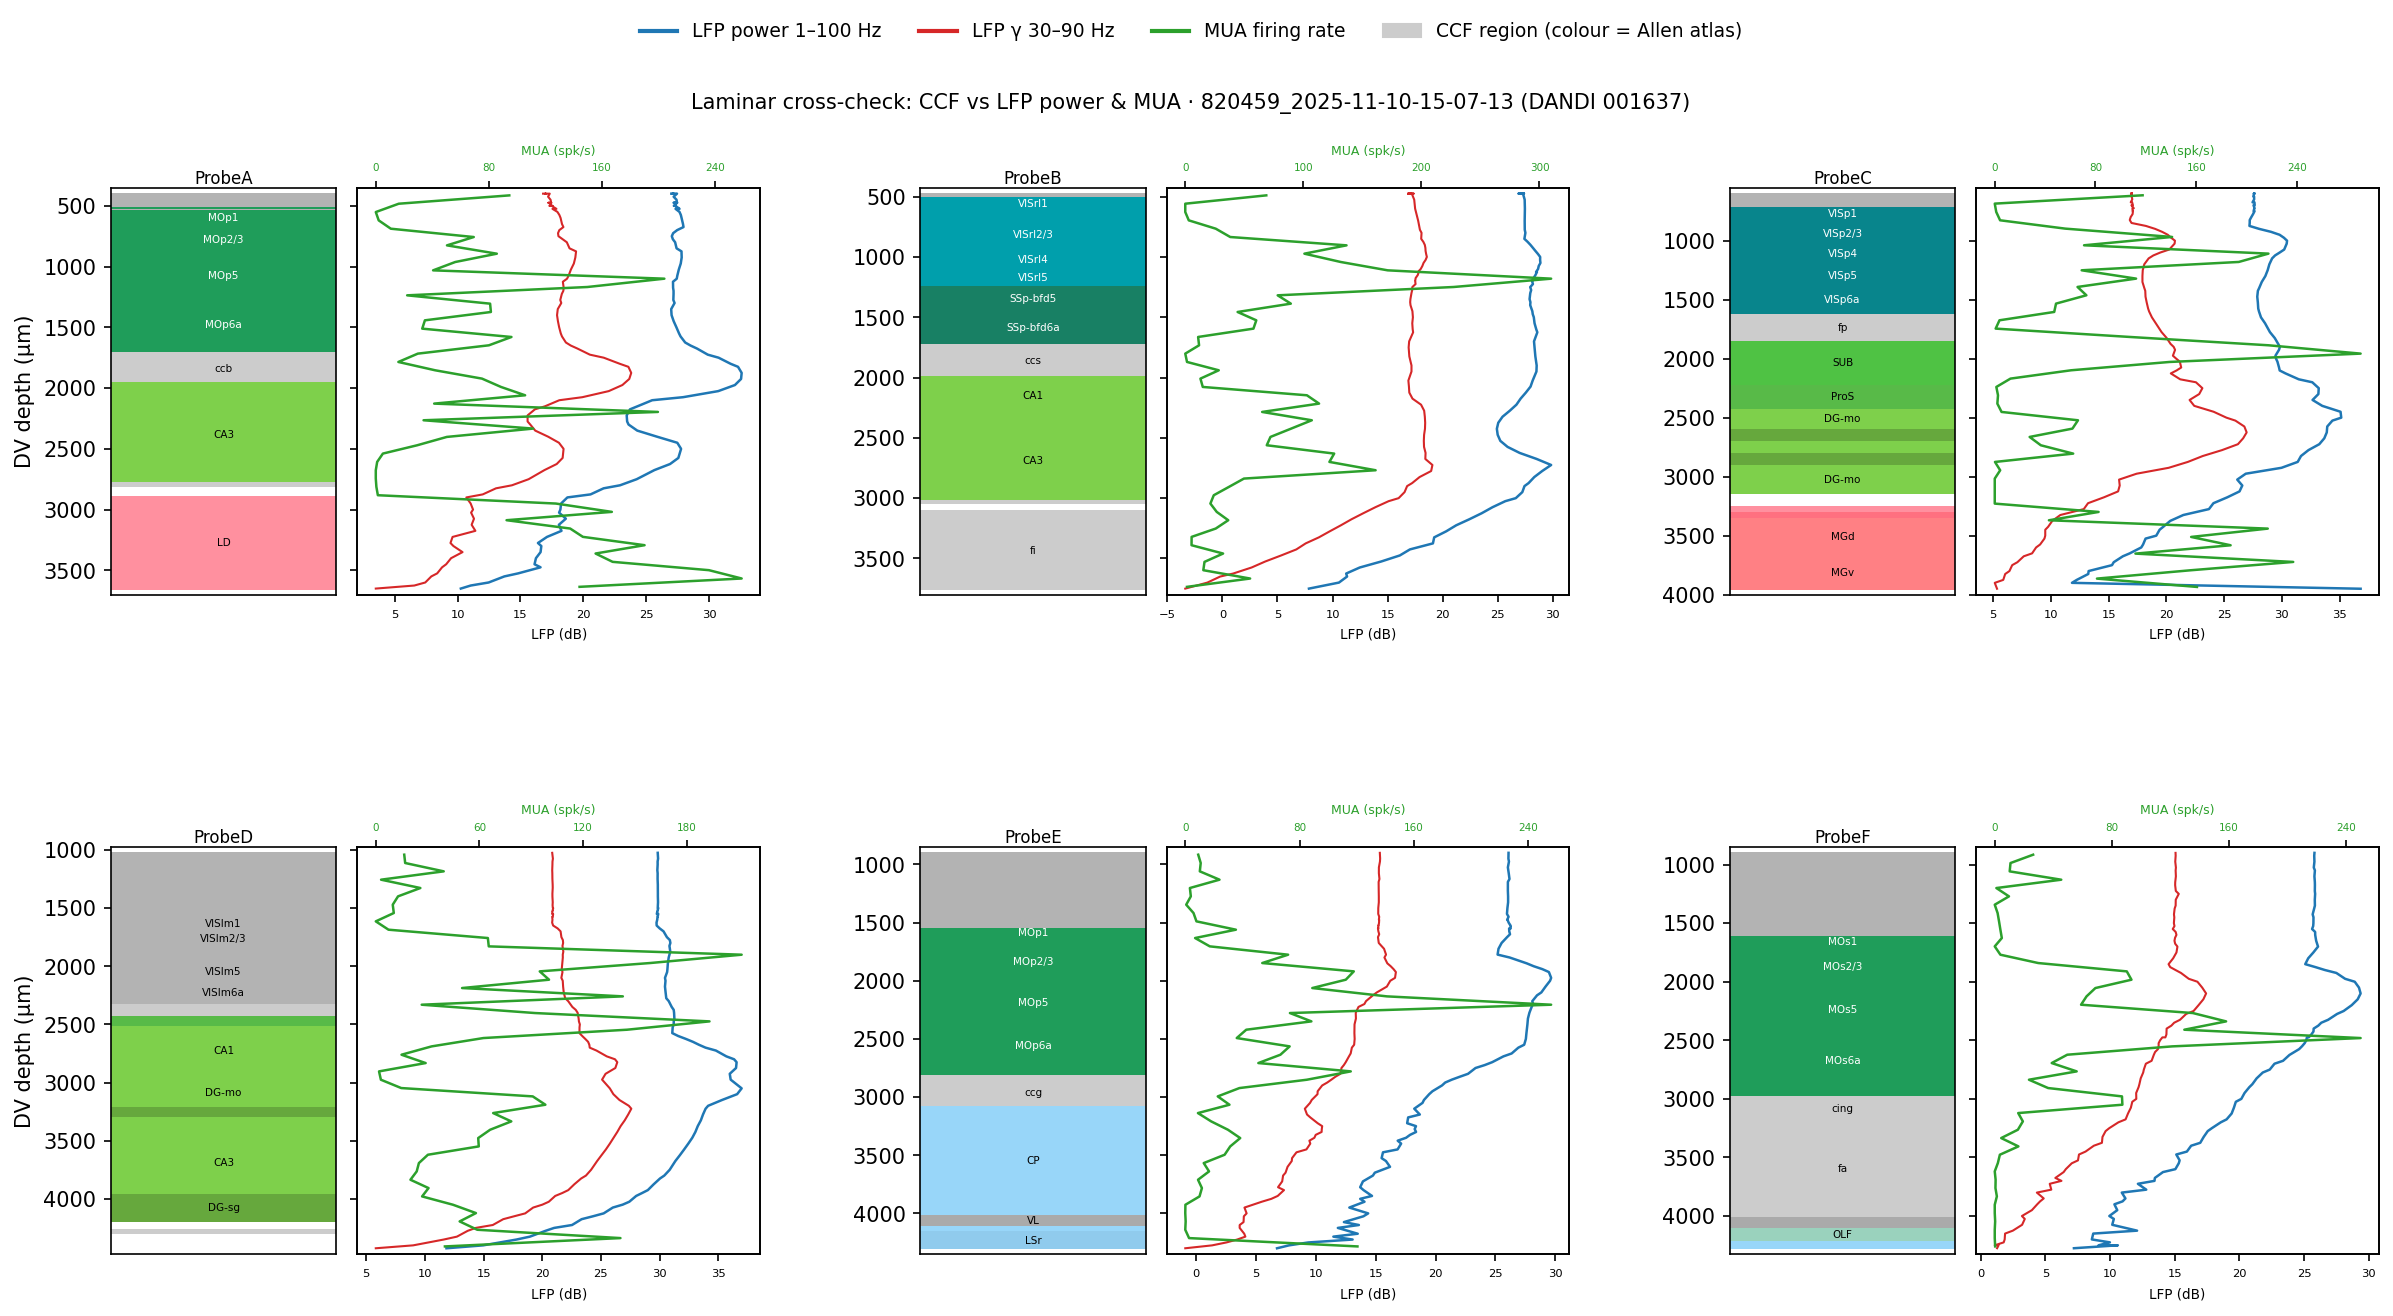

In [8]:
bg = None
try:
    from brainglobe_atlasapi import BrainGlobeAtlas
    bg = BrainGlobeAtlas("allen_mouse_25um")
except Exception:
    pass
o.make_laminar(pd_, tag, "fig_laminar.png", bg=bg)
Image("fig_laminar.png")

---
Built by the OpenScope PP CCF toolkit. Data: [DANDI 001637](https://dandiarchive.org/dandiset/001637).
CCF alignment: OpenScope community (discussion #163).